<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QGen001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Utility functions for lattice evolution

import numpy as np

def periodic_roll(a, s):
    """Roll array with periodic boundary conditions."""
    return np.roll(a, s)

def laplacian(phi):
    """Discrete Laplacian with periodic BCs."""
    return periodic_roll(phi, 1) - 2*phi + periodic_roll(phi, -1)

def clip_guard(phi, max_abs=1.0):
    """Prevent runaway growth by clipping amplitudes."""
    m = np.max(np.abs(phi))
    if m > max_abs:
        phi = phi * (max_abs / m)
    return phi


In [4]:
# Propagation cell
dt = 0.02
gamma = 0.001
lam = 0.5

def evolve(phi):
    return phi + dt*(laplacian(phi) - gamma*phi + lam*phi**3)

for t in range(2000):
    phi = evolve(phi)
    phi = clip_guard(phi, max_abs=1.0)
    if t % 100 == 0:
        history.append(phi.copy())


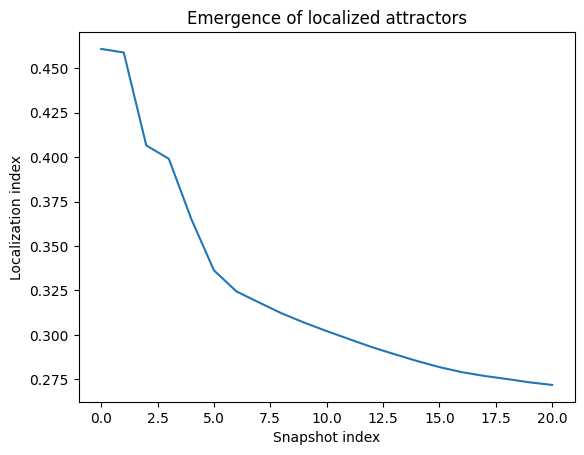

In [5]:
# Localization index
def localization(phi):
    energy = phi**2
    sorted_energy = np.sort(energy)[::-1]
    return np.sum(sorted_energy[:int(0.1*N)]) / np.sum(energy)

loc_index = [localization(h) for h in history]

plt.plot(loc_index)
plt.xlabel("Snapshot index")
plt.ylabel("Localization index")
plt.title("Emergence of localized attractors")
plt.show()


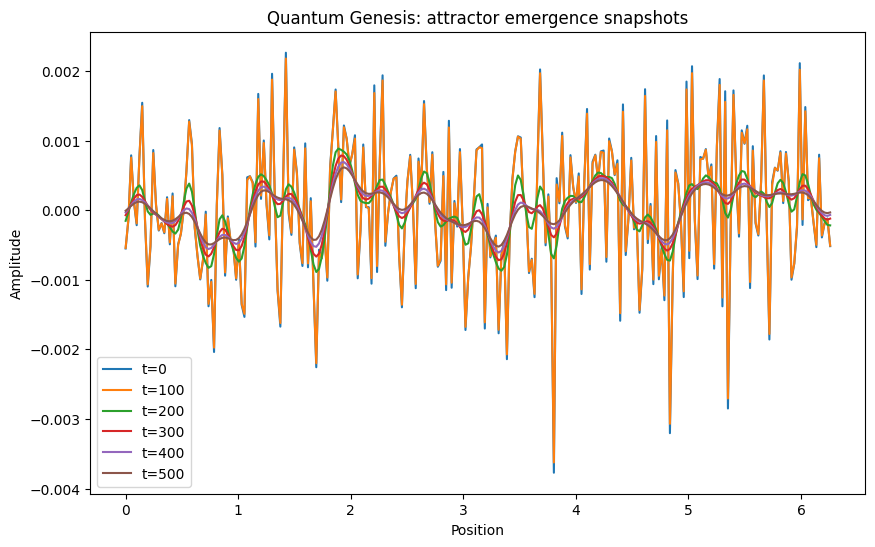

In [6]:
plt.figure(figsize=(10,6))
for i, h in enumerate(history[:6]):
    plt.plot(x, h, label=f"t={i*100}")
plt.xlabel("Position")
plt.ylabel("Amplitude")
plt.title("Quantum Genesis: attractor emergence snapshots")
plt.legend()
plt.show()
